Libraries loaded.
TensorFlow : 2.20.0
Keras      : 3.13.2

Target forecast date : 2024-12-12
Input window date    : 2024-12-11
Expected actual file : Actual_weather_data_2024_12_11.csv
Cleared:
  removed: Actual_weather_2024-12-11.csv
  removed: actual_2024-12-11.csv
  removed: saved_solar_model.zip
  removed: saved_solar_model (3).zip
  removed: saved_solar_model/

Ready for fresh uploads.
UPLOAD 1 OF 2 — Select saved_solar_model.zip


Saving saved_solar_model (3).zip to saved_solar_model (3).zip
Found    : saved_solar_model (3).zip  ✓
Renamed  : saved_solar_model (3).zip  →  saved_solar_model.zip
Extracted → saved_solar_model/
  solar_model.pkl  (335,266 bytes)  ✓
  solar_scaler.pkl  (922 bytes)  ✓
  solar_meta.pkl  (308 bytes)  ✓

saved_solar_model.zip loaded.
UPLOAD 2 OF 2 — Select actual weather for 2024-12-11
  File: Actual_weather_data_2024_12_11.csv
  Columns: Date, Temperature, Humidity, Wind speed,
           Cloud cover, Solar radiation
  Rows: 96  (15-min intervals)


Saving Actual weather data_2024.12.11.csv to Actual weather data_2024.12.11.csv
Found    : Actual weather data_2024.12.11.csv  ✓
Renamed  : Actual weather data_2024.12.11.csv  →  Actual_weather_2024-12-11.csv

Both files ready:
  saved_solar_model.zip  ✓
  Actual_weather_2024-12-11.csv  ✓
Loading model from pickle...
  Manual rebuild

Model loaded — no retraining.
  Model type : direct_96
  N_PAST     : 96  (input: 24h of weather features)
  N_FUTURE   : 96 (output: 24h of irradiance at once)
  N_FEATURES : 11
  Training   : R²=0.9054  RMSE=79.3189 W/m²

Raw file : Actual_weather_2024-12-11.csv
  Columns : ['Date', 'Temperature', 'Humidity', 'Wind speed', 'Cloud cover', 'Solar radiation']
  Shape   : (96, 6)
  File type : weather observations  ✓
  Year : 2024  ✓
  Date span : 2024-12-11 00:00:00  →  2024-12-11 23:45:00
  Rows      : 96
  Irradiance max : 559.40 W/m²
  Units correct  ✓
  After feature engineering : 92 rows
  Padded 4 rows (lag shift compensation).

Input window:
  From 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

CSV download started.


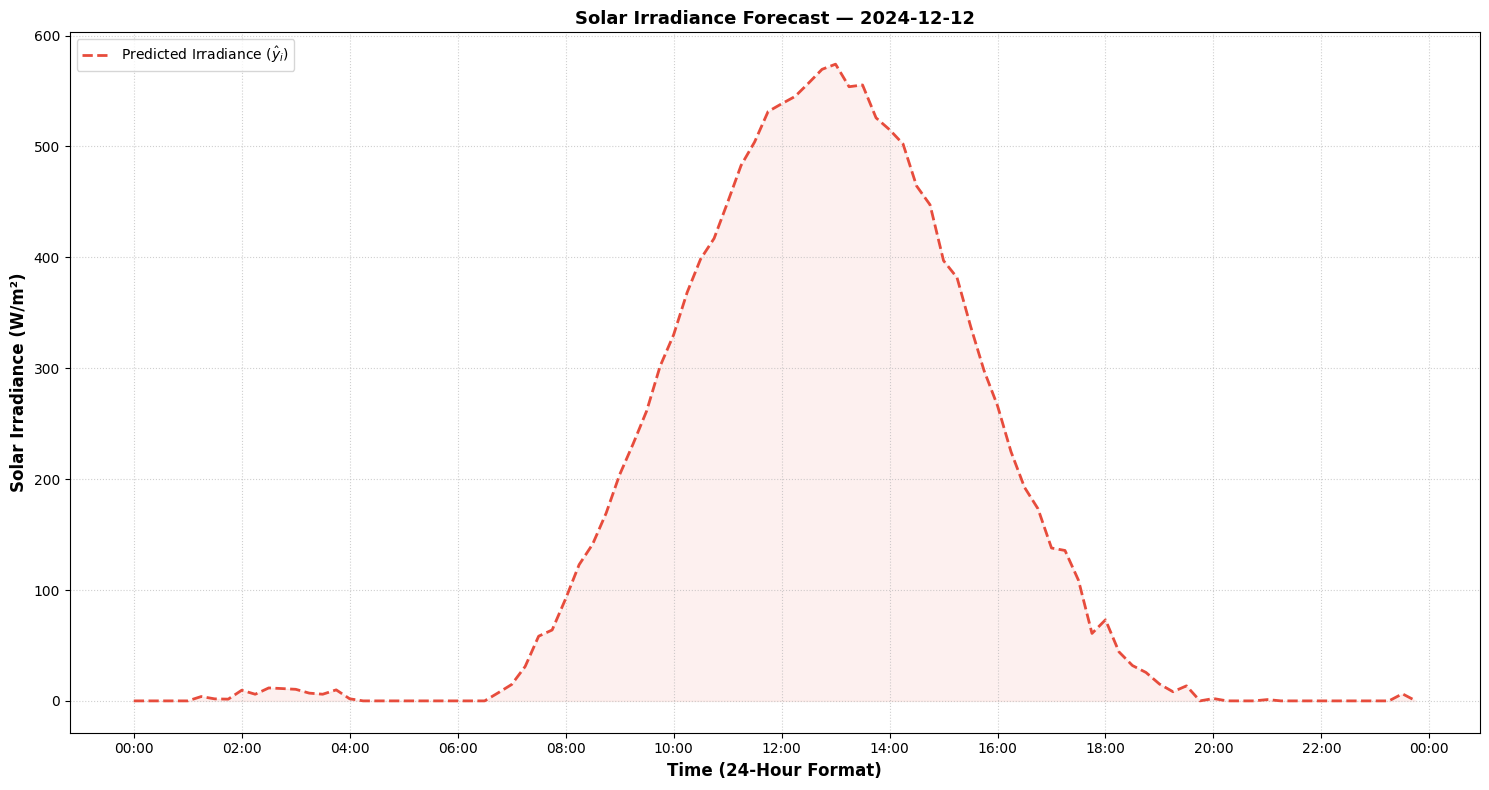

Forecast plot saved.
Individual plot and ZIP saved.


In [5]:
# =============================================================================
#  SOLAR NOTEBOOK 2 — DAILY SOLAR IRRADIANCE FORECAST
#  Run every day. No retraining ever needed.
#
#  KEY IMPROVEMENT vs previous version:
#    OLD: autoregressive loop (96 model calls, error compounds, needs
#         artificial sunset mask, peak time drifts)
#    NEW: single forward pass (1 model call, no error accumulation,
#         model learned natural bell curve from training data)
#
#  WHAT YOU UPLOAD EACH DAY (2 files):
#    1. saved_solar_model.zip              ← from Notebook 1, never changes
#    2. Actual_weather_data_YYYY_MM_DD.csv ← previous day's actual weather
#
#  ACTUAL WEATHER FILE FORMAT:
#    Columns : Date, Temperature, Humidity, Wind speed, Cloud cover,
#              Solar radiation
#    Date    : MM/DD/YYYY H:MM  e.g. 12/11/2024 0:00
#    Rows    : 96  (15-min intervals, full day)
#
#  DAILY STEPS:
#    1. Set TARGET_DATE in CELL 1
#    2. Upload saved_solar_model.zip in CELL 4
#    3. Upload actual weather CSV for PREVIOUS day in CELL 5
#    4. Run all cells → CSV + plots downloaded automatically
#
#  EXAMPLE:
#    Forecast 2024-12-12 → TARGET_DATE='2024-12-12',
#                          upload Actual_weather_data_2024_12_11.csv
#    Forecast 2024-12-13 → TARGET_DATE='2024-12-13',
#                          upload Actual_weather_data_2024_12_12.csv
#
#  IMPORTANT: Start a fresh runtime each day
#    Runtime → Disconnect and delete runtime → Reconnect
# =============================================================================


# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Configuration  *** CHANGE TARGET_DATE EVERY DAY ***
# ─────────────────────────────────────────────────────────────────────────────

TARGET_DATE = '2024-12-12'
# ↑ Date you want to FORECAST.
#   Upload actual weather for the day BEFORE this date.


# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Imports
# ─────────────────────────────────────────────────────────────────────────────
from google.colab import files as colab_files
import os, pickle, shutil, glob, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import timedelta
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

window_str = (pd.Timestamp(TARGET_DATE) - timedelta(days=1)).strftime('%Y-%m-%d')

print('Libraries loaded.')
print(f'TensorFlow : {tf.__version__}')
print(f'Keras      : {tf.keras.__version__}')
print(f'\nTarget forecast date : {TARGET_DATE}')
print(f'Input window date    : {window_str}')
print(f'Expected actual file : Actual_weather_data_{window_str.replace("-","_")}.csv')


# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Clear leftover files from previous runs
# ─────────────────────────────────────────────────────────────────────────────
removed = []
for pattern in ['Actual_weather*.csv', 'actual_weather*.csv',
                'Actual weather*.csv', 'actual_*.csv',
                'saved_solar_model*.zip']:
    for f in glob.glob(pattern):
        os.remove(f); removed.append(f)
if os.path.exists('saved_solar_model'):
    shutil.rmtree('saved_solar_model'); removed.append('saved_solar_model/')

if removed:
    print('Cleared:')
    for f in removed: print(f'  removed: {f}')
else:
    print('No previous files to clear.')
print('\nReady for fresh uploads.')


# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Upload saved_solar_model.zip  (Upload 1 of 2)
# ─────────────────────────────────────────────────────────────────────────────
print('=' * 55)
print('UPLOAD 1 OF 2 — Select saved_solar_model.zip')
print('=' * 55)

up1 = colab_files.upload()
MODEL_ZIP = next((fn for fn in up1 if 'solar_model' in fn.lower()
                  and fn.endswith('.zip')), None)
if MODEL_ZIP is None:
    raise FileNotFoundError('saved_solar_model.zip not found. Re-run this cell.')

print(f'Found    : {MODEL_ZIP}  ✓')
if MODEL_ZIP != 'saved_solar_model.zip':
    shutil.copy(MODEL_ZIP, 'saved_solar_model.zip')
    print(f'Renamed  : {MODEL_ZIP}  →  saved_solar_model.zip')

MODEL_DIR = 'saved_solar_model'
shutil.unpack_archive('saved_solar_model.zip', MODEL_DIR)
print(f'Extracted → {MODEL_DIR}/')

for fn in ['solar_model.pkl', 'solar_scaler.pkl', 'solar_meta.pkl']:
    fpath = os.path.join(MODEL_DIR, fn)
    if not os.path.exists(fpath):
        raise FileNotFoundError(
            f'{fn} missing. Re-download saved_solar_model.zip from Notebook 1.')
    print(f'  {fn}  ({os.path.getsize(fpath):,} bytes)  ✓')
print('\nsaved_solar_model.zip loaded.')


# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Upload actual weather CSV  (Upload 2 of 2)
# ─────────────────────────────────────────────────────────────────────────────
print('=' * 55)
print(f'UPLOAD 2 OF 2 — Select actual weather for {window_str}')
print(f'  File: Actual_weather_data_{window_str.replace("-","_")}.csv')
print(f'  Columns: Date, Temperature, Humidity, Wind speed,')
print(f'           Cloud cover, Solar radiation')
print(f'  Rows: 96  (15-min intervals)')
print('=' * 55)

up2 = colab_files.upload()

ACTUAL_CSV = None
for fn in up2.keys():
    m = re.search(r'(\d{4})[_\-\.](\d{2})[_\-\.](\d{2})', fn)
    if m:
        found = f'{m.group(1)}-{m.group(2)}-{m.group(3)}'
        if found == window_str:
            ACTUAL_CSV = fn; break

if ACTUAL_CSV is None:
    for fn in up2.keys():
        if fn.endswith('.csv'):
            ACTUAL_CSV = fn
            print('  Matched by file type.')
            break

if ACTUAL_CSV is None:
    raise FileNotFoundError(f'No CSV found. Uploaded: {list(up2.keys())}')

print(f'Found    : {ACTUAL_CSV}  ✓')
ACTUAL_STANDARD = f'Actual_weather_{window_str}.csv'
if ACTUAL_CSV != ACTUAL_STANDARD:
    shutil.copy(ACTUAL_CSV, ACTUAL_STANDARD)
    print(f'Renamed  : {ACTUAL_CSV}  →  {ACTUAL_STANDARD}')

print(f'\nBoth files ready:')
print(f'  saved_solar_model.zip  ✓')
print(f'  {ACTUAL_STANDARD}  ✓')


# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Load model + scaler from pickle
# ─────────────────────────────────────────────────────────────────────────────
with open(f'{MODEL_DIR}/solar_model.pkl',  'rb') as f: payload = pickle.load(f)
with open(f'{MODEL_DIR}/solar_scaler.pkl', 'rb') as f: scaler  = pickle.load(f)
with open(f'{MODEL_DIR}/solar_meta.pkl',   'rb') as f: meta    = pickle.load(f)

N_PAST      = meta['n_past']
N_FUTURE    = meta['n_future']
N_FEATURES  = meta['n_features']
FEATURES    = meta['features']
IRR_COL     = meta['irradiance_col']
MODEL_TYPE  = meta.get('model_type', 'unknown')

def _rebuild_model(payload):
    w, c = payload['weights'], payload['model_config']
    try:                                        # Keras 2.x
        m = tf.keras.models.model_from_config(c)
        m.set_weights(w); print('  Keras 2.x'); return m
    except Exception: pass
    try:                                        # Keras 3.x
        import keras
        m = keras.saving.model_from_config(c)
        m.set_weights(w); print('  Keras 3.x'); return m
    except Exception: pass
    # Manual rebuild — BiLSTM(64+32) + Dense(96) matching Notebook 1
    np_, nf, nf_ = payload['n_past'], payload['n_features'], payload['n_future']
    m = Sequential([
        Bidirectional(LSTM(64, activation='relu', return_sequences=True),
                      input_shape=(np_, nf)),
        Dropout(0.1),
        Bidirectional(LSTM(32, activation='relu')),
        Dropout(0.1),
        Dense(16, activation='relu'),
        Dense(nf_),   # nf_ = N_FUTURE = 96
    ])
    m.set_weights(w); print('  Manual rebuild'); return m

print('Loading model from pickle...')
model = _rebuild_model(payload)
model.compile(optimizer='adam', loss='mse')

print(f'\nModel loaded — no retraining.')
print(f'  Model type : {MODEL_TYPE}')
print(f'  N_PAST     : {N_PAST}  (input: 24h of weather features)')
print(f'  N_FUTURE   : {N_FUTURE} (output: 24h of irradiance at once)')
print(f'  N_FEATURES : {N_FEATURES}')
if 'metrics' in meta:
    mm = meta['metrics']
    print(f'  Training   : R²={mm["r2"]:.4f}  RMSE={mm["rmse"]:.4f} W/m²')

if MODEL_TYPE != 'direct_96':
    print('\nWARNING: This pickle was made with the OLD model (single-step output).')
    print('For best results retrain Notebook 1 to get a direct_96 pickle.')


# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Load, validate and prepare the actual weather CSV
#
#  The actual weather file provides the 96-row input window.
#  Feature engineering must exactly match Notebook 1.
# ─────────────────────────────────────────────────────────────────────────────
df_raw = pd.read_csv(ACTUAL_STANDARD)

print(f'\nRaw file : {ACTUAL_STANDARD}')
print(f'  Columns : {df_raw.columns.tolist()}')
print(f'  Shape   : {df_raw.shape}')

# Validate it is a weather file not a forecast output
WEATHER_COLS = ['Temperature', 'Temp', 'Humidity', 'Wind speed', 'WindSpeed',
                'Cloud cover', 'CloudCover', 'Solar radiation', 'Irradiance']
if not any(c in df_raw.columns for c in WEATHER_COLS):
    raise ValueError(
        f'\n*** WRONG FILE ***\n'
        f'Columns found: {df_raw.columns.tolist()}\n'
        f'Expected: Date, Temperature, Humidity, Wind speed,\n'
        f'          Cloud cover, Solar radiation\n'
        f'You may have uploaded a forecast CSV. Re-run CELL 5.')

print(f'  File type : weather observations  ✓')

# Find date column
date_col = next((c for c in ['Date','date','DATE','Timestamp','timestamp']
                 if c in df_raw.columns), None)
if date_col is None:
    raise ValueError(f'No date column. Columns: {df_raw.columns.tolist()}')
if date_col != 'Date':
    df_raw = df_raw.rename(columns={date_col: 'Date'})

df_raw['Date'] = pd.to_datetime(df_raw['Date'], infer_datetime_format=True)

# Auto-correct wrong year
target_year  = pd.Timestamp(TARGET_DATE).year
current_year = df_raw['Date'].dt.year.iloc[0]
if current_year != target_year:
    print(f'  Year correction : {current_year} → {target_year}')
    df_raw['Date'] = df_raw['Date'].apply(lambda d: d.replace(year=target_year))
else:
    print(f'  Year : {current_year}  ✓')

df_raw.set_index('Date', inplace=True)
df_raw.sort_index(inplace=True)
df_raw.rename(columns={
    'Solar radiation': 'Irradiance',
    'Temperature'    : 'Temp',
    'Humidity'       : 'Humidity',
    'Wind speed'     : 'WindSpeed',
    'Cloud cover'    : 'CloudCover',
}, inplace=True)

print(f'  Date span : {df_raw.index[0]}  →  {df_raw.index[-1]}')
print(f'  Rows      : {len(df_raw)}')

# Resample to 15-min if hourly
if len(df_raw) <= 25:
    df_raw = df_raw.resample('15min').ffill()
    print(f'  Resampled hourly → 15-min: {len(df_raw)} rows')

# Clean
df_raw = df_raw.dropna(how='all')
df_raw = df_raw[df_raw.index.notna()]
df_raw = df_raw.dropna(how='any')

# Irradiance unit check
irr_max = df_raw['Irradiance'].max()
print(f'  Irradiance max : {irr_max:.2f} W/m²')
if irr_max < 5:
    df_raw['Irradiance'] = df_raw['Irradiance'] * 1000
    print(f'  RESCALED ×1000 → {df_raw["Irradiance"].max():.2f} W/m²')
elif irr_max >= 50:
    print(f'  Units correct  ✓')

# Feature engineering — must exactly match Notebook 1
df_raw['Hour']        = df_raw.index.hour + df_raw.index.minute / 60
df_raw['Hour_sin']    = np.sin(2 * np.pi * df_raw['Hour'] / 24)
df_raw['Hour_cos']    = np.cos(2 * np.pi * df_raw['Hour'] / 24)
df_raw['Day_of_Year'] = df_raw.index.dayofyear
df_raw['Day_sin']     = np.sin(2 * np.pi * df_raw['Day_of_Year'] / 365.25)
df_raw['Day_cos']     = np.cos(2 * np.pi * df_raw['Day_of_Year'] / 365.25)
df_raw['Irr_lag1']    = df_raw['Irradiance'].shift(1)
df_raw['Irr_lag4']    = df_raw['Irradiance'].shift(4)
df_raw.dropna(inplace=True)

df_feat = df_raw[FEATURES].copy().dropna(how='any')
print(f'  After feature engineering : {len(df_feat)} rows')

# Pad rows lost to shift(4) — 96-row file → 92 rows after lag dropna
if len(df_feat) < N_PAST:
    shortfall = N_PAST - len(df_feat)
    pad = pd.DataFrame(
        [df_feat.iloc[0].values] * shortfall,
        columns=df_feat.columns,
        index=pd.date_range(
            end=df_feat.index[0] - pd.Timedelta('15min'),
            periods=shortfall, freq='15min'))
    df_feat = pd.concat([pad, df_feat])
    print(f'  Padded {shortfall} rows (lag shift compensation).')

window_96_df = df_feat.iloc[-N_PAST:]
print(f'\nInput window:')
print(f'  From     : {window_96_df.index[0]}')
print(f'  To       : {window_96_df.index[-1]}')
print(f'  Irr max  : {window_96_df["Irradiance"].max():.2f} W/m²')
print(f'  NaN      : {window_96_df.isnull().sum().sum()}')
print('\nValidation passed ✓')


# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Generate forecast  (SINGLE forward pass — no loop)
#
#  The model takes 96 rows of yesterday's weather as input and directly
#  outputs all 96 irradiance values for tomorrow in ONE model.predict() call.
#
#  This eliminates:
#   - Autoregressive error accumulation (each step no longer feeds back)
#   - Artificial sunset/sunrise time masking
#   - Peak time drift (model learned the bell curve from training)
#   - 96-call inference latency (now just 1 call, ~1 second)
# ─────────────────────────────────────────────────────────────────────────────
target_date = pd.Timestamp(TARGET_DATE)

print(f'Generating forecast for  {TARGET_DATE}  ...')
print(f'Input window : {window_96_df.index[0]}  →  {window_96_df.index[-1]}')
print(f'Method       : direct 96-step output (single model.predict() call)')

# Scale input
window_96 = window_96_df.values.copy()
window_sc = scaler.transform(window_96)           # (96, 11)

print(f'Scaled — min: {window_sc.min():.4f}  '
      f'max: {window_sc.max():.4f}  '
      f'NaN: {np.isnan(window_sc).sum()}')

if np.isnan(window_sc).any():
    raise ValueError('NaN in scaled input — check actual CSV.')

# Single forward pass — model outputs all 96 values at once
inp      = window_sc.reshape(1, N_PAST, N_FEATURES)  # (1, 96, 11)
pred_sc  = model.predict(inp, verbose=0).flatten()    # (96,) directly

print(f'Raw prediction — min: {pred_sc.min():.4f}  max: {pred_sc.max():.4f}')

# Inverse transform
dummy             = np.zeros((N_FUTURE, N_FEATURES))
dummy[:, IRR_COL] = pred_sc
pred_irr          = scaler.inverse_transform(dummy)[:, IRR_COL]

# Clip negatives only — no hard time masking needed
# The model learned from training data when irradiance is zero (night)
pred_irr = np.clip(pred_irr, 0, None)

# Build forecast Series
forecast_times  = pd.date_range(start=target_date, periods=N_FUTURE, freq='15min')
forecast_series = pd.Series(pred_irr, index=forecast_times,
                            name='Solar_Irradiance_Wm2')
forecast_series.index.name = 'Timestamp'

print(f'\nForecast stats (W/m²):')
print(f'  Min  : {pred_irr.min():.2f}')
print(f'  Max  : {pred_irr.max():.2f}')
print(f'  Mean : {pred_irr.mean():.2f}')

print(f'\nForecast complete — single forward pass.')
print(f'  Period : {forecast_series.index[0]}  →  {forecast_series.index[-1]}')

print(f'\nHourly preview:')
for t, v in zip(forecast_series.index[::4], forecast_series.values[::4]):
    print(f'  {t.strftime("%H:%M")}  →  {v:.2f} W/m²')


# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Save CSV + plots
# ─────────────────────────────────────────────────────────────────────────────
out_dir   = f'Solar_Forecast_{TARGET_DATE}'
plots_dir = os.path.join(out_dir, 'Solar_Forecast_Plots')
os.makedirs(plots_dir, exist_ok=True)

# 1. Forecast CSV
csv_path = os.path.join(out_dir,
                        f'solar_Forecast.csv')
forecast_series.to_csv(csv_path, header=True)
print(f'Forecast CSV  →  {csv_path}')
colab_files.download(csv_path)
print('CSV download started.')

# 2. Daily forecast plot
fig, ax = plt.subplots(figsize=(15, 8))
ax.plot(forecast_series.index, forecast_series.values,
        label=r'Predicted Irradiance ($\hat{y}_i$)',
        color='#E74C3C', linestyle='--', linewidth=2)
ax.fill_between(forecast_series.index, forecast_series.values,
                color='#E74C3C', alpha=0.08)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.set_xlabel('Time (24-Hour Format)', fontsize=12, fontweight='bold')
ax.set_ylabel('Solar Irradiance (W/m²)', fontsize=12, fontweight='bold')
ax.set_title(f'Solar Irradiance Forecast — {TARGET_DATE}',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, f'Solar_Forecast_{TARGET_DATE}.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Forecast plot saved.')

# 3. Individual PNG
plt.figure(figsize=(10, 5))
plt.plot(forecast_series.index, forecast_series.values,
         label='Forecast', color='#E74C3C', linestyle='--', linewidth=2)
plt.title(f'Solar Irradiance Forecast: {TARGET_DATE}')
plt.xlabel('Time (24-Hour Format)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend(); plt.grid(True, linestyle=':', alpha=0.6)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, f'solar_forecast_{TARGET_DATE}.png'),
            dpi=300, bbox_inches='tight')
plt.close()
shutil.make_archive(os.path.join(out_dir, 'Solar_Forecasts_All'),
                    'zip', plots_dir)
print('Individual plot and ZIP saved.')




Actual file found: Actual weather data_2024.12.12.csv

--- Evaluation: Forecast vs Actual (2024-12-12) ---
R²   : 0.7246
RMSE : 77.7938 W/m²
MAE  : 42.0316 W/m²
MSE  : 6051.8723


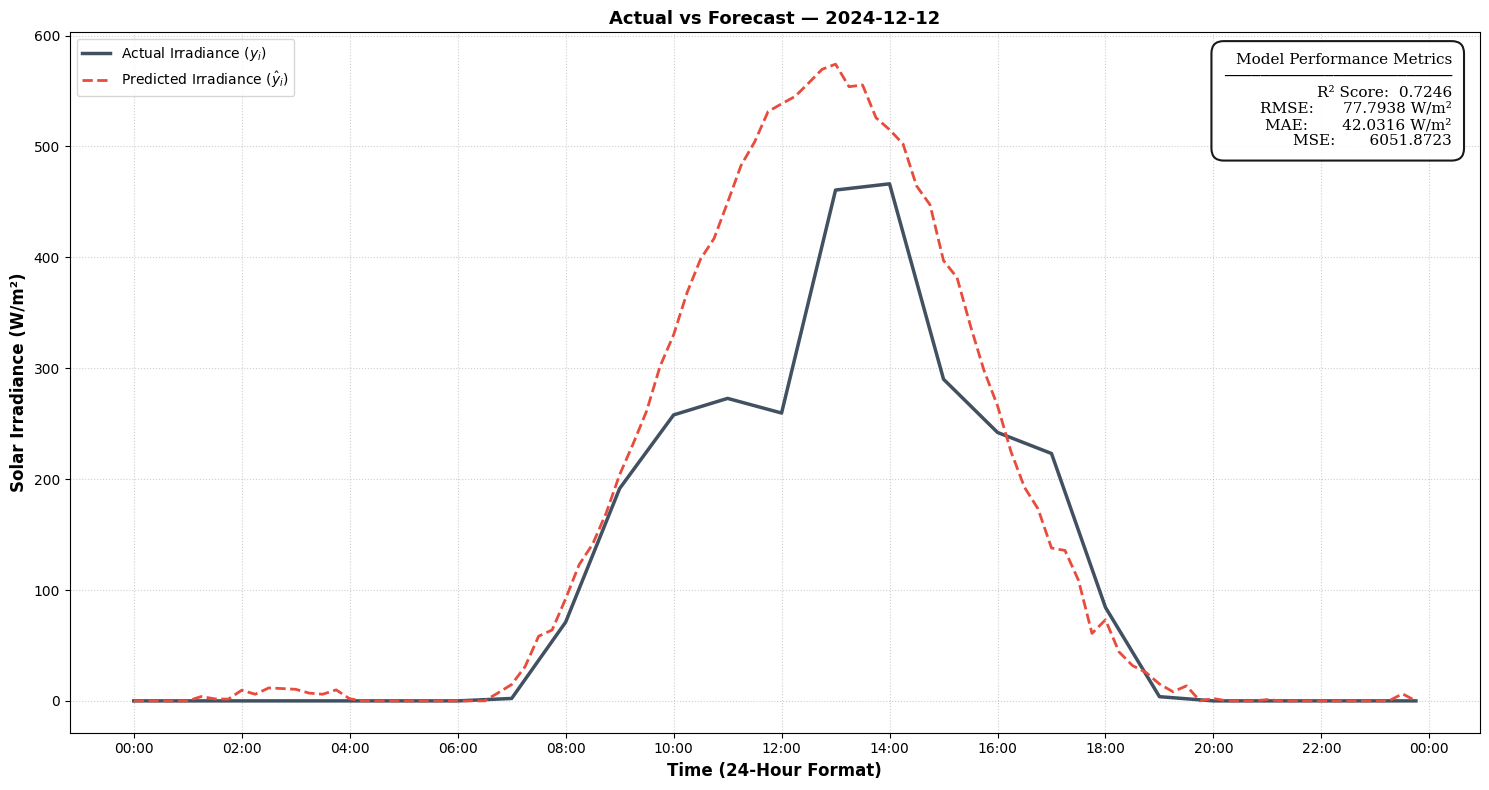

Overlay plots → Solar_Forecast_2024-12-12/Overlay_Plots/
Master ZIP → Solar_Forecast_2024-12-12.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.

OUTPUT FILE TREE  —  Solar_Forecast_2024-12-12/
Solar_Forecast_2024-12-12/
  Solar_Forecast_2024-12-12.png  (140,441 bytes)
  Solar_Forecasts_All.zip  (147,741 bytes)
  solar_Forecast.csv  (3,307 bytes)
  Solar_Forecast_Plots/
    solar_forecast_2024-12-12.png  (182,426 bytes)
  Overlay_Plots/
    Actual_vs_Forecast_2024-12-12.png  (192,999 bytes)
    solar_overlay_2024-12-12.png  (225,363 bytes)


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — Optional: evaluate forecast vs actual
#
#  Upload actual weather CSV for TARGET_DATE and run this cell.
#  Skip if actual data is not yet available.
# ─────────────────────────────────────────────────────────────────────────────
actual_found = None
for fn in os.listdir('.'):
    if not fn.endswith('.csv'): continue
    m = re.search(r'(\d{4})[_\-\.](\d{2})[_\-\.](\d{2})', fn)
    if m and f'{m.group(1)}-{m.group(2)}-{m.group(3)}' == TARGET_DATE:
        actual_found = fn; break

if actual_found:
    print(f'Actual file found: {actual_found}')
    df_act = pd.read_csv(actual_found)
    dcol = next((c for c in ['Date','date','Timestamp','timestamp']
                 if c in df_act.columns), None)

    if dcol:
        if dcol != 'Date': df_act = df_act.rename(columns={dcol: 'Date'})
        df_act['Date'] = pd.to_datetime(df_act['Date'],
                                         infer_datetime_format=True)
        ty = pd.Timestamp(TARGET_DATE).year
        if df_act['Date'].dt.year.iloc[0] != ty:
            df_act['Date'] = df_act['Date'].apply(lambda d: d.replace(year=ty))
        df_act.set_index('Date', inplace=True)
        df_act.sort_index(inplace=True)
        df_act.rename(columns={'Solar radiation': 'Irradiance'}, inplace=True)
        df_act = df_act.dropna(how='all')
        df_act = df_act[df_act.index.notna()].dropna(how='any')
        if df_act['Irradiance'].max() < 5:
            df_act['Irradiance'] = df_act['Irradiance'] * 1000

        a = df_act['Irradiance'].values
        p = forecast_series.values
        n = min(len(a), len(p))
        a, p  = a[:n], p[:n]
        t_ax  = pd.date_range(start=target_date, periods=n, freq='15min')

        mse  = mean_squared_error(a, p)
        rmse = np.sqrt(mse)
        mae  = mean_absolute_error(a, p)
        r2   = r2_score(a, p)

        print(f'\n--- Evaluation: Forecast vs Actual ({TARGET_DATE}) ---')
        print(f'R²   : {r2:.4f}')
        print(f'RMSE : {rmse:.4f} W/m²')
        print(f'MAE  : {mae:.4f} W/m²')
        print(f'MSE  : {mse:.4f}')

        overlay_dir = os.path.join(out_dir, 'Overlay_Plots')
        os.makedirs(overlay_dir, exist_ok=True)

        fig, ax = plt.subplots(figsize=(15, 8))
        ax.plot(t_ax, a, label='Actual Irradiance ($y_i$)',
                color='#2C3E50', linewidth=2.5, alpha=0.9)
        ax.plot(t_ax, p, label=r'Predicted Irradiance ($\hat{y}_i$)',
                color='#E74C3C', linestyle='--', linewidth=2)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))

        stats_box = (f'Model Performance Metrics\n{"─"*25}\n'
                     f'R² Score:  {r2:.4f}\n'
                     f'RMSE:      {rmse:.4f} W/m²\n'
                     f'MAE:       {mae:.4f} W/m²\n'
                     f'MSE:       {mse:.4f}')
        ax.text(0.98, 0.97, stats_box, transform=ax.transAxes,
                fontsize=11, va='top', ha='right', fontfamily='serif',
                bbox=dict(boxstyle='round,pad=0.8', facecolor='white',
                          alpha=0.9, edgecolor='black', linewidth=1.5))

        ax.set_xlabel('Time (24-Hour Format)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Solar Irradiance (W/m²)', fontsize=12, fontweight='bold')
        ax.set_title(f'Actual vs Forecast — {TARGET_DATE}',
                     fontsize=13, fontweight='bold')
        ax.legend(loc='upper left', frameon=True)
        ax.grid(True, linestyle=':', alpha=0.6)
        plt.tight_layout()
        plt.savefig(os.path.join(overlay_dir,
                    f'Actual_vs_Forecast_{TARGET_DATE}.png'),
                    dpi=150, bbox_inches='tight')
        plt.show()

        plt.figure(figsize=(10, 5))
        plt.plot(t_ax, a, label='Actual',   color='#2C3E50', lw=2, alpha=0.9)
        plt.plot(t_ax, p, label='Forecast', color='#E74C3C', lw=2, ls='--')
        plt.title(f'Actual vs Forecast  (R²: {r2:.4f})')
        plt.xlabel('Time (24-Hour Format)')
        plt.ylabel('Solar Irradiance (W/m²)')
        plt.legend(); plt.grid(True, linestyle=':', alpha=0.6)
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=2))
        plt.tight_layout()
        plt.savefig(os.path.join(overlay_dir,
                    f'solar_overlay_{TARGET_DATE}.png'),
                    dpi=300, bbox_inches='tight')
        plt.close()
        print(f'Overlay plots → {overlay_dir}/')
else:
    print(f'No actual file for {TARGET_DATE} — evaluation skipped.')
    print(f'Upload actual weather CSV for {TARGET_DATE} and re-run this cell.')


# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — Download everything as one ZIP
# ─────────────────────────────────────────────────────────────────────────────
zip_name = f'Solar_Forecast_{TARGET_DATE}'
shutil.make_archive(zip_name, 'zip', out_dir)
print(f'Master ZIP → {zip_name}.zip')
colab_files.download(f'{zip_name}.zip')
print('Download started.')

print(f'\nOUTPUT FILE TREE  —  {out_dir}/')
print('=' * 55)
for root, dirs, fnames in os.walk(out_dir):
    depth  = root.replace(out_dir, '').count(os.sep)
    indent = '  ' * depth
    print(f'{indent}{os.path.basename(root)}/')
    for fn in sorted(fnames):
        size = os.path.getsize(os.path.join(root, fn))
        print(f"{'  '*(depth+1)}{fn}  ({size:,} bytes)")